# CNN: Training Keras (16 Arsitektur)

Notebook ini hanya mengerjakan bagian CNN untuk dataset Intel Image Classification. RNN dan LSTM tidak dipakai di sini.

## Setup

In [1]:
from pathlib import Path
import json
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.wajib.cnn.models import runExperiments
from src.wajib.cnn.utils import loadBatch, loadDataset

import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_ROOT = PROJECT_ROOT / "data"
TRAIN_DIR = DATA_ROOT / "seg_train" / "seg_train"
TEST_DIR = DATA_ROOT / "seg_test" / "seg_test"
WEIGHTS_DIR = PROJECT_ROOT / "src" / "wajib" / "weights" / "cnn"
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

TARGET_SIZE = (64, 64)
BATCH_SIZE = 32
EPOCHS = 10
VALIDATION_SIZE = 0.2
MAX_PER_CLASS = None  # isi integer kecil, misalnya 250, kalau ingin smoke test cepat

I0000 00:00:1778778669.109955  432887 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Load + Split Dataset

In [2]:
train_paths, train_labels, class_names = loadDataset(str(TRAIN_DIR))
test_paths, test_labels, _ = loadDataset(str(TEST_DIR), class_names=class_names)

def limit_per_class(paths, labels, max_per_class):
    if max_per_class is None:
        return paths, labels
    kept_paths, kept_labels = [], []
    per_class_count = {idx: 0 for idx in range(len(class_names))}
    for path, label in zip(paths, labels):
        if per_class_count[label] < max_per_class:
            kept_paths.append(path)
            kept_labels.append(label)
            per_class_count[label] += 1
    return kept_paths, kept_labels

train_paths, train_labels = limit_per_class(train_paths, train_labels, MAX_PER_CLASS)
test_paths, test_labels = limit_per_class(test_paths, test_labels, MAX_PER_CLASS)

train_paths, val_paths, y_train, y_val = train_test_split(
    train_paths,
    train_labels,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    stratify=train_labels,
)

print("Classes:", class_names)
print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")


Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train: 11227 | Val: 2807 | Test: 3000


## Convert Gambar to Array

In [3]:
X_train = loadBatch(train_paths, target_size=TARGET_SIZE)
X_val = loadBatch(val_paths, target_size=TARGET_SIZE)
X_test = loadBatch(test_paths, target_size=TARGET_SIZE)

y_train = np.asarray(y_train, dtype=np.int64)
y_val = np.asarray(y_val, dtype=np.int64)
y_test = np.asarray(test_labels, dtype=np.int64)

input_shape = X_train.shape[1:]
num_classes = len(class_names)

print("Input shape:", input_shape)
print("Num classes:", num_classes)


Input shape: (64, 64, 3)
Num classes: 6


## Train 16 arsitektur CNN

In [4]:
results = runExperiments(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    input_shape=input_shape,
    num_classes=num_classes,
    weights_dir=str(WEIGHTS_DIR),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

with open(WEIGHTS_DIR / "class_names.json", "w", encoding="utf-8") as f:
    json.dump(class_names, f, indent=2)



EXPERIMENT #1: cnn_conv_L2_F32-64_K3-3_Pmax
--------------------------------------------------
Layers  : 2
Filters : [32, 64]
Kernels : [3, 3]
Pooling : max
Batch   : 32 | Epochs: 10



I0000 00:00:1778778692.041676  432887 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2526 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5
W0000 00:00:1778778693.794881  432887 cpu_allocator_impl.cc:82] Allocation of 551829504 exceeds 10% of free system memory.
W0000 00:00:1778778694.497439  432887 cpu_allocator_impl.cc:82] Allocation of 551829504 exceeds 10% of free system memory.


Epoch 1/10


I0000 00:00:1778778696.938424  433264 service.cc:153] XLA service 0x7fb050038730 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778778696.938441  433264 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1650, Compute Capability 7.5 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1778778696.993490  433264 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778778697.343200  433264 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1778778697.460803  433264 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2728__.43


 15/351 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.2824 - loss: 8.8985

...

351/351 ━━━━━━━━━━━━━━━━━━━━ 30s 62ms/step - accuracy: 0.4818 - loss: 1.5672 - val_accuracy: 0.2679 - val_loss: 4.9926
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.5909 - loss: 1.0729 - val_accuracy: 0.4011 - val_loss: 1.9923
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.6467 - loss: 0.9528 - val_accuracy: 0.5444 - val_loss: 1.3445
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.6834 - loss: 0.8688 - val_accuracy: 0.4332 - val_loss: 3.1349
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.7115 - loss: 0.8015 - val_accuracy: 0.5447 - val_loss: 1.3057
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.7306 - loss: 0.7567 - val_accuracy: 0.7827 - val_loss: 0.6317
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.7591 - loss: 0.6761 - val_accuracy: 0.6484 - val_loss: 0.9730
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.7736 - loss: 0.6352 - val_accurac

I0000 00:00:1778780092.905197  433265 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_350811__.47


349/351 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4410 - loss: 1.9476

I0000 00:00:1778780110.154535  433265 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_350811__.47


351/351 ━━━━━━━━━━━━━━━━━━━━ 30s 52ms/step - accuracy: 0.4983 - loss: 1.4701 - val_accuracy: 0.1763 - val_loss: 3.6090
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.5796 - loss: 1.0871 - val_accuracy: 0.5404 - val_loss: 1.3186
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.6263 - loss: 0.9895 - val_accuracy: 0.6523 - val_loss: 0.9009
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.6573 - loss: 0.9240 - val_accuracy: 0.7082 - val_loss: 0.8264
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.6925 - loss: 0.8404 - val_accuracy: 0.6014 - val_loss: 1.0571
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.7255 - loss: 0.7626 - val_accuracy: 0.6516 - val_loss: 0.9265
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.7424 - loss: 0.7150 - val_accuracy: 0.6056 - val_loss: 0.9850
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.7638 - loss: 0.6668 - val_accurac

## Hasil Eksperimen

In [5]:
rows = []
for item in results:
    rows.append({
        "name": item["name"],
        "num_conv_layers": item["config"]["num_conv_layers"],
        "num_filters": item["config"]["num_filters"],
        "filter_sizes": item["config"]["filter_sizes"],
        "pooling_type": item["config"]["pooling_type"],
        "accuracy": item["metrics"]["accuracy"],
        "macro_f1": item["metrics"]["macro_f1"],
        "params": item["params"],
        "weights_path": item["weights_path"],
    })

results_df = pd.DataFrame(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
results_df.to_csv(WEIGHTS_DIR / "cnn_experiment_results.csv", index=False)
display(results_df)

best_result = results_df.iloc[0]
print("Best model:", best_result["name"])
print("Best weights:", best_result["weights_path"])


,name,num_conv_layers,num_filters,filter_sizes,pooling_type,accuracy,macro_f1,params,weights_path
0,cnn_conv_L3_F32-64-64_K3-3-3_Paverage,3,"[32, 64, 64]","[3, 3, 3]",average,0.792667,0.794427,1107334,/home/stahlynx/Coding/Semester-6/ML/Tejumama_I...
1,cnn_conv_L3_F64-128-128_K3-3-3_Pmax,3,"[64, 128, 128]","[3, 3, 3]",max,0.787000,0.792543,2323462,/home/stahlynx/Coding/Semester-6/ML/Tejumama_I...
2,cnn_conv_L3_F64-128-128_K5-5-5_Pmax,3,"[64, 128, 128]","[5, 5, 5]",max,0.786667,0.788389,2719750,/home/stahlynx/Coding/Semester-6/ML/Tejumama_I...
3,cnn_conv_L2_F32-64_K3-3_Paverage,2,"[32, 64]","[3, 3]",average,0.785333,0.787253,4215878,/home/stahlynx/Coding/Semester-6/ML/Tejumama_I...
4,cnn_conv_L3_F32-64-64_K3-3-3_Pmax,3,"[32, 64, 64]","[3, 3, 3]",max,0.777000,0.779358,1107334,/home/stahlynx/Coding/Semester-6/ML/Tejumama_I...
5,cnn_conv_L3_F64-128-128_K3-3-3_Paverage,3,"[64, 128, 128]","[3, 3, 3]",average,0.776667,0.778327,2323462,/home/stahlynx/Coding/Semester-6/ML/Tejumama_I...
6,cnn_conv_L2_F32-64_K3-3_Pmax,2,"[32, 64]","[3, 3]",max,0.774667,0.777829,4215878,/home/stahlynx/Coding/Semester-6/ML/Tejumama_I...
7,cnn_conv_L3_F32-64-64_K5-5-5_Paverage,3,"[32, 64, 64]","[5, 5, 5]",average,0.772000,0.775631,1207174,/home/stahlynx/Coding/Semester-6/ML/Tejumama_I...
8,cnn_conv_L2_F64-128_K3-3_Paverage,2,"[64, 128]","[3, 3]",average,0.770667,0.772467,8466822,/home/stahlynx/Coding/Semester-6/ML/Tejumama_I...
9,cnn_conv_L3_F64-128-128_K5-5-5_Paverage,3,"[64, 128, 128]","[5, 5, 5]",average,0.766667,0.767762,2719750,/home/stahlynx/Coding/Semester-6/ML/Tejumama_I...


Best model: cnn_conv_L3_F32-64-64_K3-3-3_Paverage
Best weights: /home/stahlynx/Coding/Semester-6/ML/Tejumama_Image-Captioning/src/wajib/weights/cnn/cnn_conv_L3_F32-64-64_K3-3-3_Paverage.keras


## Analisis

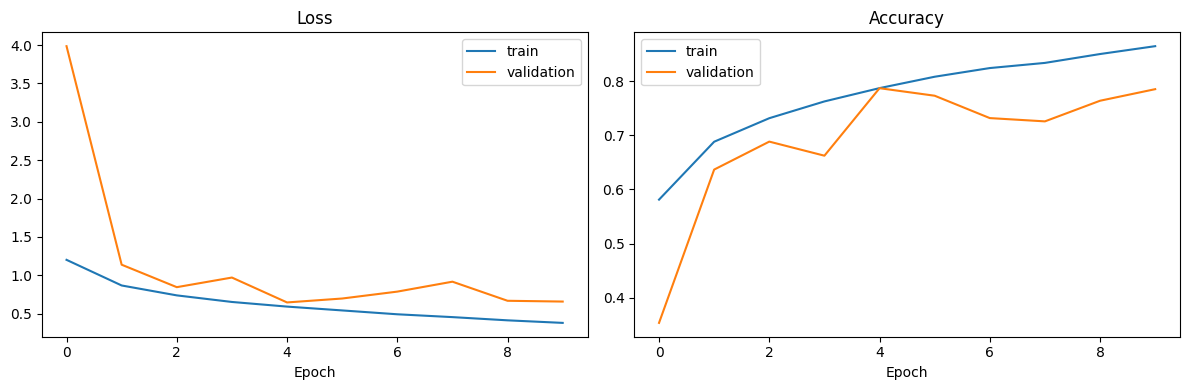

In [19]:
best_name = best_result["name"]
best_history = next(item["history"] for item in results if item["name"] == best_name)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(best_history["loss"], label="train")
axes[0].plot(best_history["val_loss"], label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(best_history["accuracy"], label="train")
axes[1].plot(best_history["val_accuracy"], label="validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


# Buat Liat Hasil Prediksi

Berhasil memuat model: cnn_conv_L3_F32-64-64_K3-3-3_Paverage
Path: /home/stahlynx/Coding/Semester-6/ML/Tejumama_Image-Captioning/src/wajib/weights/cnn/cnn_conv_L3_F32-64-64_K3-3-3_Paverage.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


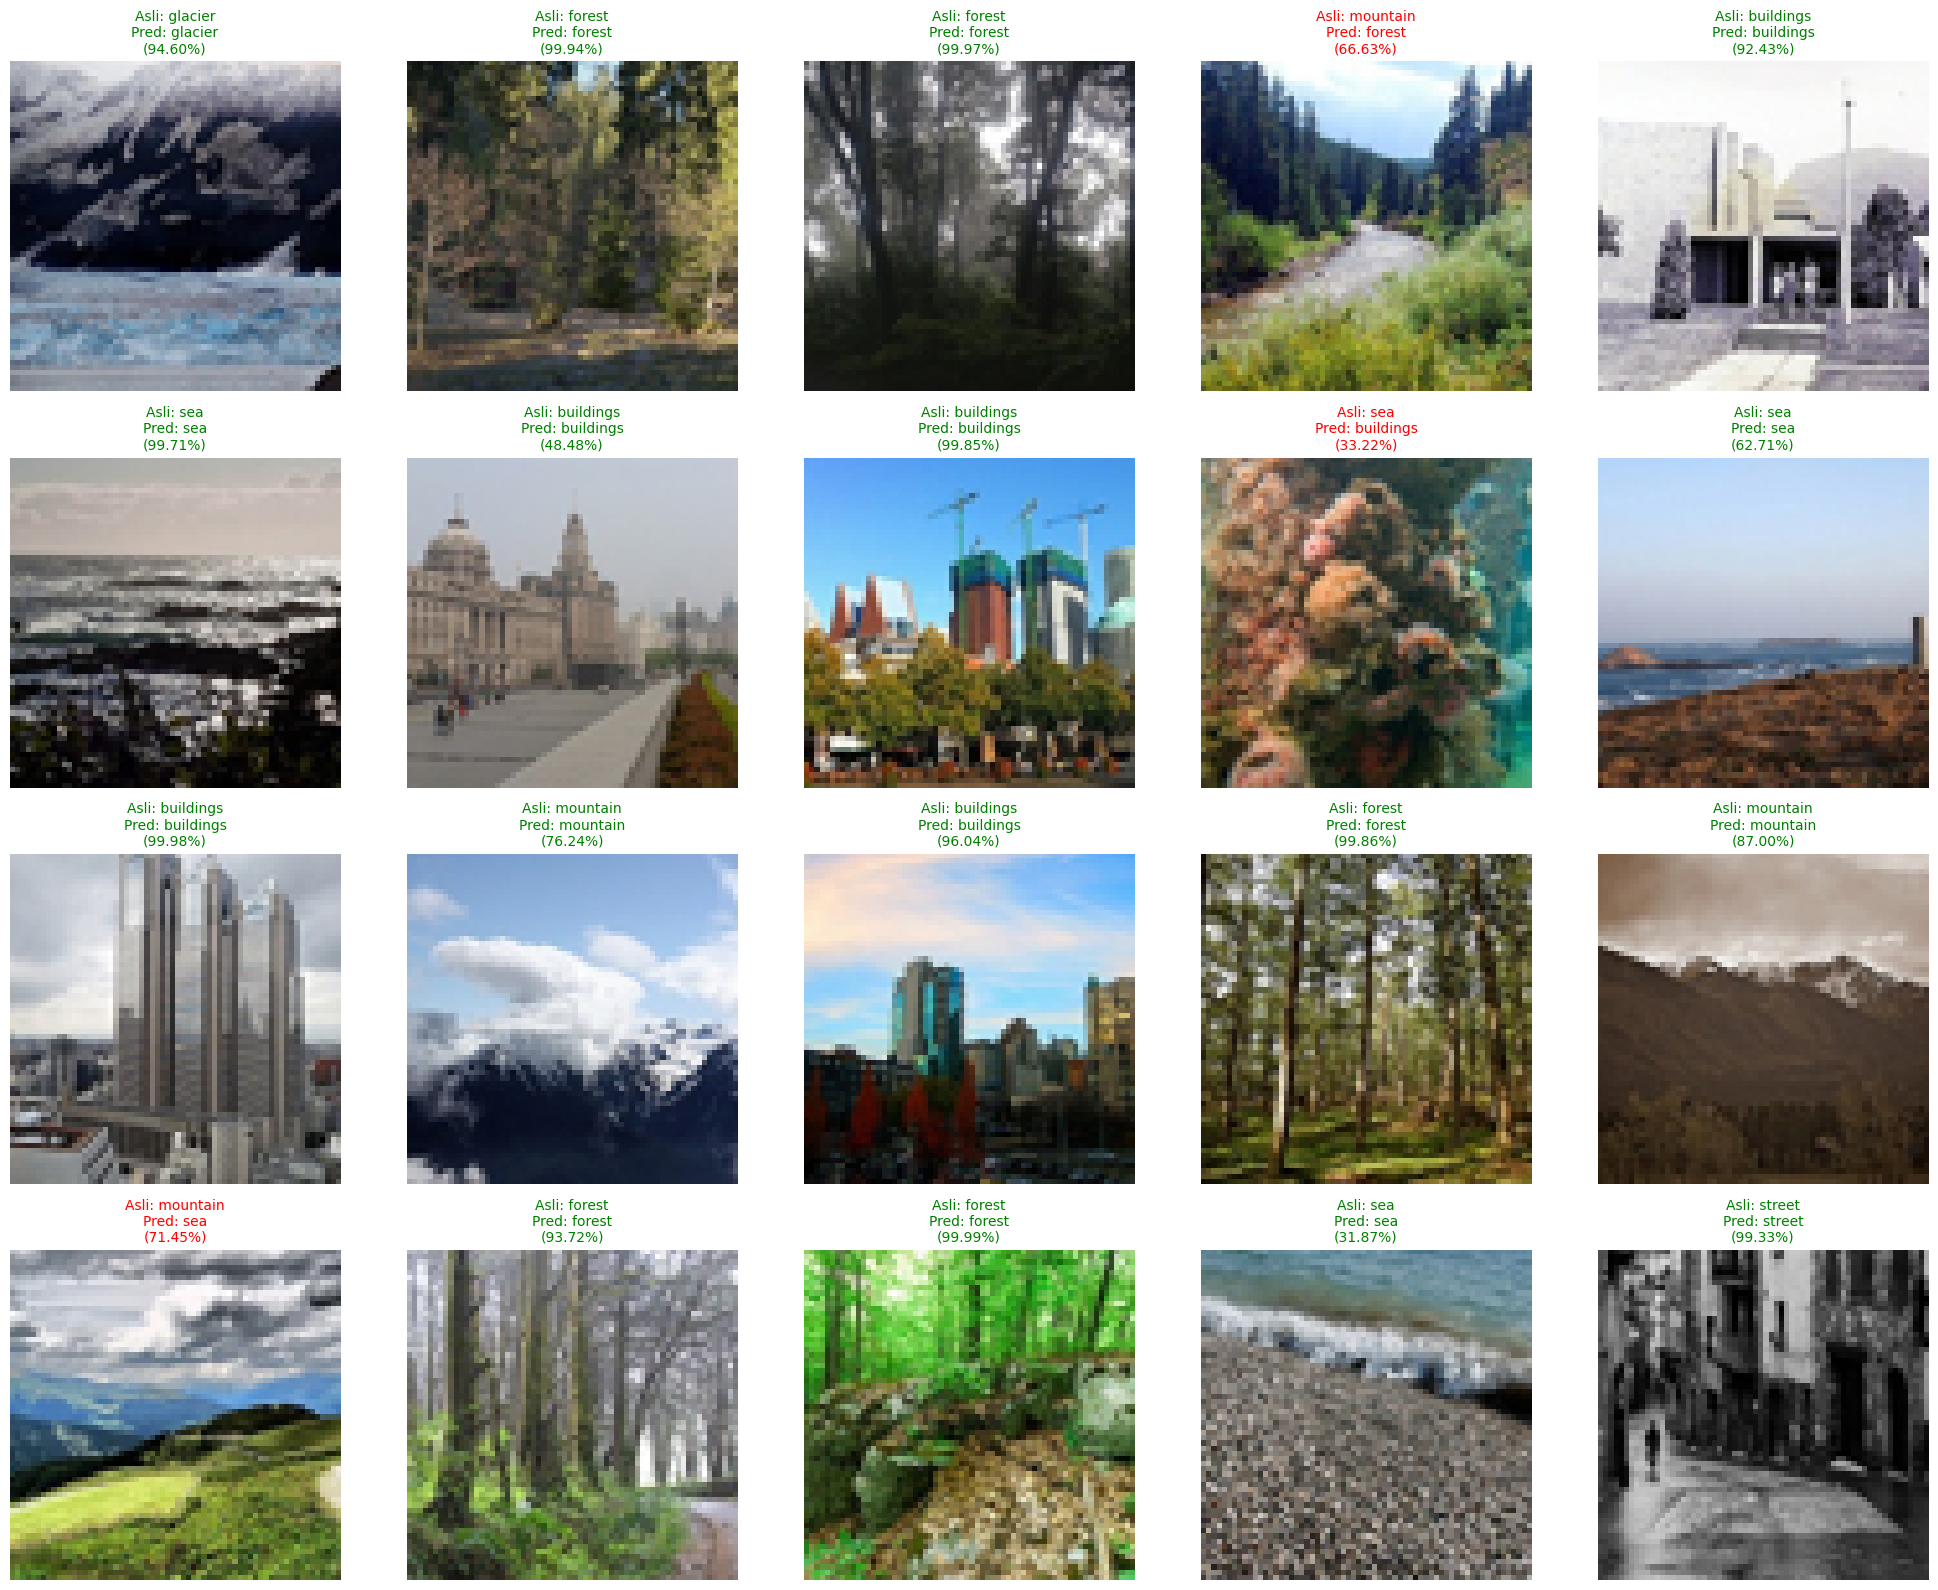

In [14]:
import tensorflow as tf
from src.wajib.cnn.models import CNN

best_item = next(item for item in results if item["name"] == best_result["name"])

model = CNN(
    input_shape=input_shape,
    num_classes=num_classes,
    num_conv_layers=best_item["config"]["num_conv_layers"],
    num_filters=best_item["config"]["num_filters"],
    filter_sizes=best_item["config"]["filter_sizes"],
    pooling_type=best_item["config"]["pooling_type"]
)

model.load_weights(best_item["weights_path"])
print(f"Berhasil memuat model: {best_item['name']}")
print(f"Path: {best_item['weights_path']}")

predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

num_images = 20 

plt.figure(figsize=(20, 16)) 
random_indices = np.random.choice(len(X_test), num_images, replace=False)

for i, idx in enumerate(random_indices):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_test[idx])
    
    label_asli = class_names[y_test[idx]]
    label_pred = class_names[predicted_classes[idx]]
    probabilitas = np.max(predictions[idx])
    
    warna = "green" if label_asli == label_pred else "red"
    
    plt.title(f"Asli: {label_asli}\nPred: {label_pred}\n({probabilitas:.2%})", 
              color=warna, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()